# Chapter 5 — Gaussian elimination and LU factorization

**Numerical Linear Algebra: Theory, Algorithms, and Computation**

**Abdallah Alsammani, Ph.D.**  
Department of Mathematical Sciences & Data Science  
Delaware State University

Lecture notes: <https://aalsammani.github.io/numerical-linear-algebra/>  
Notes for this chapter: <https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html>  
Repository: <https://github.com/aalsammani/Numerical-Linear-Algebra-Notebooks>

This notebook is the computational laboratory of the chapter; the theory,
proofs and exercises are in the lecture notes, to which the links below
point. References such as Trefethen and Bau (1997) are listed in the
[bibliography of the notes](https://aalsammani.github.io/numerical-linear-algebra/back/bibliography.html). Version
1.0, September 2026.

---

This notebook accompanies [Chapter 5](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05) of the notes. Every
experiment checks a statement from the chapter numerically.

**Learning objectives.** After working through this lab you should be able to

1. implement forward and back substitution and verify their componentwise
   backward stability;
2. implement LU factorization without pivoting and with partial pivoting
   using vectorized rank-one updates, and handle an exactly zero pivot
   correctly;
3. verify a factorization against `scipy.linalg.lu` with the correct
   residual $\|A - PLU\|$ and with the bound $|\Delta A|\le\gamma_n|L||U|$;
4. reproduce the failure of unpivoted elimination caused by a small pivot;
5. measure growth factors on random matrices and on the Wilkinson matrix, and
   explain what each experiment does and does not show;
6. compare backward error, forward error and $\kappa(A)u$ for LU with
   partial pivoting;
7. use `lu_factor` and `lu_solve` efficiently and explain why one never
   forms $A^{-1}$ to solve a system.

Run the cells in order from a fresh kernel.

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.linalg as sla

rng = np.random.default_rng(20260927)
u = np.finfo(float).eps / 2          # unit roundoff of IEEE double precision, 2**-53
plt.rcParams.update({"figure.figsize": (6.4, 4.0), "axes.grid": True, "grid.alpha": 0.3})


def gamma(k):
    """Higham's constant gamma_k = k u / (1 - k u)."""
    return k * u / (1 - k * u)


print(f"NumPy {np.__version__}, SciPy {scipy.__version__}; unit roundoff u = {u:.3e}")

NumPy 2.5.3, SciPy 1.18.1; unit roundoff u = 1.110e-16


## 1. Triangular systems

Forward substitution solves $Ly = b$ from the top down and back substitution
solves $Ux = y$ from the bottom up (equation [(5.1)](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#equation-ch05-eq-back-sub)). Each
costs $n^2$ flops. The inner loop is written as a NumPy inner product, so the
only Python loop is over the rows.

In [2]:
def forward_sub(L, b, unit=False):
    """Solve L y = b for lower triangular L (unit diagonal assumed if unit=True)."""
    n = L.shape[0]
    y = np.array(b, dtype=float)
    for i in range(n):
        y[i] -= L[i, :i] @ y[:i]
        if not unit:
            if L[i, i] == 0:
                raise np.linalg.LinAlgError(f"zero diagonal entry at row {i}")
            y[i] /= L[i, i]
    return y


def back_sub(U, y):
    """Solve U x = y for upper triangular U by back substitution."""
    n = U.shape[0]
    x = np.array(y, dtype=float)
    for i in range(n - 1, -1, -1):
        if U[i, i] == 0:
            raise np.linalg.LinAlgError(f"zero diagonal entry at row {i}")
        x[i] = (x[i] - U[i, i + 1:] @ x[i + 1:]) / U[i, i]
    return x


# The worked example of the notes (Example "A triangular solve by hand").
U_ex = np.array([[2.0, 1.0, 1.0], [0.0, 1.0, 1.0], [0.0, 0.0, 2.0]])
print(back_sub(U_ex, [4.0, 2.0, 2.0]))
assert np.array_equal(back_sub(U_ex, [4.0, 2.0, 2.0]), [1.0, 1.0, 1.0])   # exact: all operations are exact

[1. 1. 1.]


**Backward stability.** [Theorem 5.1](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05-thm-triangular) says that the computed
$\hat x$ satisfies $(T+\Delta T)\hat x = b$ with $|\Delta T|\le\gamma_n|T|$.
The smallest such componentwise relative perturbation of $T$ is the
Oettli--Prager backward error
$\omega = \max_i |b - T\hat x|_i / (|T||\hat x|)_i$, so the theorem predicts
$\omega\le\gamma_n$. The residual is itself computed in floating point, with
an error of at most $\gamma_{n+1}(|b| + |T||\hat x|)\le\gamma_{n+1}(2+\gamma_n)|T||\hat x|$,
so we test $\omega\le\gamma_n + 3\gamma_{n+1}$.

Random triangular matrices are notoriously ill conditioned, which makes the
contrast between backward and forward error visible.

In [3]:
def omega_componentwise(T, x, b):
    """Oettli-Prager backward error with perturbations of T only (b exact)."""
    r = b - T @ x
    return np.max(np.abs(r) / (np.abs(T) @ np.abs(x)))


print("  n    kappa_2(T)   forward error   omega/u   bound gamma_n/u")
for n in (10, 20, 40, 80):
    T = np.triu(rng.standard_normal((n, n))) + np.diag(np.sign(rng.standard_normal(n)))
    x_true = rng.standard_normal(n)
    b = T @ x_true
    x_hat = back_sub(T, b)
    om = omega_componentwise(T, x_hat, b)
    fwd = np.linalg.norm(x_hat - x_true) / np.linalg.norm(x_true)
    print(f"{n:4d}   {np.linalg.cond(T):10.2e}   {fwd:12.2e}   {om / u:7.2f}   {gamma(n) / u:9.1f}")
    assert om <= gamma(n) + 3 * gamma(n + 1)

  n    kappa_2(T)   forward error   omega/u   bound gamma_n/u
  10     2.24e+03       2.59e-14      1.18        10.0
  20     9.84e+02       1.48e-15      0.67        20.0
  40     1.96e+08       4.19e-10      1.50        40.0
  80     8.81e+17       2.99e-02      1.37        80.0


The componentwise backward error is a small multiple of $u$ in every case,
far below the worst-case $\gamma_n$. The forward error, in contrast, grows
with $\kappa_2(T)$: backward stability transfers the difficulty to the
conditioning of the problem ([Chapter 4](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04)).

## 2. LU factorization without pivoting

[Algorithm 5.2](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05-alg-lu) overwrites a copy of $A$ with the multipliers (strict
lower triangle) and $U$ (upper triangle). Step $k$ is a division of a column
by the pivot and a rank-one update of the trailing submatrix; in NumPy both
are single array operations. An exactly zero pivot before the last step
means that the factorization does not exist or is not unique
([Theorem 5.2](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05-thm-lu-exists)), and we raise an error.

In [4]:
def lu_nopivot(A):
    """LU factorization without pivoting: A = L U. Raises on an exactly zero pivot."""
    A = np.array(A, dtype=float)
    n = A.shape[0]
    for k in range(n - 1):
        if A[k, k] == 0.0:
            raise np.linalg.LinAlgError(f"zero pivot at step {k + 1}: no unique LU without pivoting")
        A[k + 1:, k] /= A[k, k]                                          # multipliers
        A[k + 1:, k + 1:] -= np.outer(A[k + 1:, k], A[k, k + 1:])        # rank-one update
    return np.tril(A, -1) + np.eye(n), np.triu(A)


A3 = np.array([[2.0, 1.0, 1.0], [4.0, 3.0, 3.0], [8.0, 7.0, 9.0]])
L3, U3 = lu_nopivot(A3)
print("L =\n", L3, "\nU =\n", U3)
assert np.array_equal(L3, [[1, 0, 0], [2, 1, 0], [4, 3, 1]])     # all operations exact for this A
assert np.array_equal(U3, [[2, 1, 1], [0, 1, 1], [0, 0, 2]])
x3 = back_sub(U3, forward_sub(L3, [4.0, 10.0, 24.0], unit=True))
print("solution of A x = (4, 10, 24):", x3)
assert np.array_equal(x3, [1.0, 1.0, 1.0])

L =
 [[1. 0. 0.]
 [2. 1. 0.]
 [4. 3. 1.]] 
U =
 [[2. 1. 1.]
 [0. 1. 1.]
 [0. 0. 2.]]
solution of A x = (4, 10, 24): [1. 1. 1.]


**Verification with a justified tolerance.** By [Theorem 5.4](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05-thm-lu-backward)
the computed factors satisfy $|A - \hat L\hat U|\le\gamma_n|\hat L||\hat U|$.
Evaluating $\hat L\hat U$ in floating point adds another error of at most
$\gamma_n|\hat L||\hat U|$, so the computed residual must satisfy the
entrywise bound $2\gamma_n|\hat L||\hat U|$ plus one rounding of the
subtraction. We test on a matrix that is strictly diagonally dominant by
columns, for which no pivoting is needed ([Exercise 5.6](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05-ex-diag-dominant)).

In [5]:
n = 300
A = rng.standard_normal((n, n))
A += np.diag(np.sum(np.abs(A), axis=0) + 1.0)     # strictly diagonally dominant by columns
L, U = lu_nopivot(A)
LU_abs = np.abs(L) @ np.abs(U)
resid = np.abs(A - L @ U)
print(f"max |A - LU| / (|L||U|)  = {np.max(resid / LU_abs) / u:.2f} u   (bound 2 gamma_n = {2 * gamma(n) / u:.0f} u)")
print(f"max |l_ij| = {np.max(np.abs(np.tril(L, -1))):.3f}")
assert np.all(resid <= (2 * gamma(n) + u) * LU_abs)

max |A - LU| / (|L||U|)  = 21.61 u   (bound 2 gamma_n = 600 u)
max |l_ij| = 0.018


## 3. LU factorization with partial pivoting

[Algorithm 5.3](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05-alg-gepp) adds a pivot search and an interchange of entire
rows of the working array, which also interchanges the multipliers already
stored. We record the permutation as an index vector `perm` with
`A[perm] = L @ U`, that is $PA = LU$ with $P$ = `np.eye(n)[perm]`. The
function also returns

- `info`: $0$ if all pivots are nonzero, otherwise the (1-based) index of the
  first exactly zero pivot, as in LAPACK's `getrf`; in that case the active
  column is already zero, nothing needs to be eliminated, and the
  factorization $PA = LU$ remains exact with a singular $U$;
- `rho`: the growth factor [(5.7)](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#equation-ch05-eq-growth), the largest entry of any
  intermediate matrix divided by the largest entry of $A$.

In [6]:
def lu_partial(A):
    """LU with partial pivoting. Returns perm, L, U, info, rho with A[perm] = L @ U."""
    A = np.array(A, dtype=float)
    n = A.shape[0]
    perm = np.arange(n)
    info = 0
    amax = np.max(np.abs(A))
    top = amax
    for k in range(n - 1):
        p = k + int(np.argmax(np.abs(A[k:, k])))      # first index of the largest |a_ik|, i >= k
        if p != k:
            A[[k, p]] = A[[p, k]]                      # whole rows, including stored multipliers
            perm[[k, p]] = perm[[p, k]]
        if A[k, k] == 0.0:                            # the whole active column is zero
            info = info or k + 1
            continue                                   # nothing to eliminate; A[perm] = L U stays exact
        A[k + 1:, k] /= A[k, k]
        A[k + 1:, k + 1:] -= np.outer(A[k + 1:, k], A[k, k + 1:])
        top = max(top, np.max(np.abs(A[k + 1:, k + 1:])))
    if info == 0 and A[n - 1, n - 1] == 0.0:
        info = n
    rho = top / amax if amax > 0 else 1.0
    return perm, np.tril(A, -1) + np.eye(n), np.triu(A), info, rho


def lu_solve_mine(perm, L, U, b):
    """Solve A x = b from A[perm] = L U: L y = b[perm], then U x = y."""
    return back_sub(U, forward_sub(L, np.asarray(b, dtype=float)[perm], unit=True))


perm, L, U, info, rho = lu_partial(A3)
print("perm =", perm, " info =", info)
print("L =\n", L, "\nU =\n", U)
assert list(perm) == [2, 0, 1] and info == 0                   # rows 3, 1, 2 of A, as in the notes
assert np.allclose(L, [[1, 0, 0], [1 / 4, 1, 0], [1 / 2, 2 / 3, 1]], rtol=0, atol=2 * u)
assert np.allclose(U, [[8, 7, 9], [0, -3 / 4, -5 / 4], [0, 0, -2 / 3]], rtol=0, atol=8 * u)

perm = [2 0 1]  info = 0
L =
 [[1.         0.         0.        ]
 [0.25       1.         0.        ]
 [0.5        0.66666667 1.        ]] 
U =
 [[ 8.          7.          9.        ]
 [ 0.         -0.75       -1.25      ]
 [ 0.          0.         -0.66666667]]


**Comparison with SciPy.** `scipy.linalg.lu` returns `P, L, U` with
$A = PLU$. Its `P` is therefore the transpose of our $P$. The correct
residual is $\|A - PLU\|$. The legacy version of this course printed
$\|PA - LU\|$ with SciPy's `P`, obtained a value of order $\|A\|$ and did not
comment on it; the next cell shows why that number is meaningless. The
tolerance for the correct residual comes from [Theorem 5.4](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05-thm-lu-backward)
as in Section 2, in normwise form:
$\|A - PLU\|_\infty\le2\gamma_n\||L||U|\|_\infty$ (plus rounding of the
subtraction).

In [7]:
n = 200
A = rng.standard_normal((n, n))
P_sp, L_sp, U_sp = sla.lu(A)
perm, L, U, info, rho = lu_partial(A)
P_mine = np.eye(n)[perm]

normA = np.linalg.norm(A, np.inf)
bound = (2 * gamma(n) + u) * np.linalg.norm(np.abs(L_sp) @ np.abs(U_sp), np.inf) / normA
print(f"SciPy:  ||A - P L U|| / ||A||     = {np.linalg.norm(A - P_sp @ L_sp @ U_sp, np.inf) / normA:.2e}"
      f"   (bound {bound:.2e})")
print(f"SciPy:  ||P A - L U|| / ||A||     = {np.linalg.norm(P_sp @ A - L_sp @ U_sp, np.inf) / normA:.2e}"
      "   <- wrong formula for SciPy's P")
print(f"ours:   ||P A - L U|| / ||A||     = {np.linalg.norm(P_mine @ A - L @ U, np.inf) / normA:.2e}")
print(f"same permutation: {np.array_equal(P_mine, P_sp.T)};  max|L - L_scipy| = {np.max(np.abs(L - L_sp)):.1e};"
      f"  max|U - U_scipy| / max|U| = {np.max(np.abs(U - U_sp)) / np.max(np.abs(U)):.1e}")
print(f"max |l_ij| = {np.max(np.abs(np.tril(L, -1))):.3f};  growth factor rho = {rho:.2f}")
assert np.linalg.norm(A - P_sp @ L_sp @ U_sp, np.inf) / normA <= bound
assert np.array_equal(P_mine, P_sp.T)
assert np.max(np.abs(L)) <= 1.0

SciPy:  ||A - P L U|| / ||A||     = 1.70e-15   (bound 4.94e-12)
SciPy:  ||P A - L U|| / ||A||     = 1.45e+00   <- wrong formula for SciPy's P
ours:   ||P A - L U|| / ||A||     = 1.99e-15
same permutation: True;  max|L - L_scipy| = 2.5e-14;  max|U - U_scipy| / max|U| = 8.6e-15
max |l_ij| = 1.000;  growth factor rho = 9.68


Our factors agree with LAPACK's to within a small multiple of $u$ times a
modest amplification factor: the two codes make the same pivot choices but
perform the additions in different orders (LAPACK uses a blocked algorithm),
so the rounding errors differ.

**An exactly zero pivot.** For the singular matrix below, the first two
columns are equal, so after step 1 the active part of column 2 is exactly
zero. `lu_partial` records `info = 2` and still returns an exact
factorization with $u_{22} = 0$; SciPy (LAPACK `getrf`) does the same and
issues a warning.

In [8]:
A_sing = np.array([[1.0, 1.0, 1.0], [2.0, 2.0, 5.0], [4.0, 4.0, 6.0]])
perm, L, U, info, rho = lu_partial(A_sing)
print("info =", info, "\nU =\n", U)
print("A[perm] - L U =\n", A_sing[perm] - L @ U)
assert info == 2 and np.array_equal(A_sing[perm], L @ U)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    lu_sp, piv_sp = sla.lu_factor(A_sing)
print("SciPy warning:", caught[0].message if caught else None)

info = 2 
U =
 [[ 4.   4.   6. ]
 [ 0.   0.   2. ]
 [ 0.   0.  -0.5]]
A[perm] - L U =
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
SciPy warning: Diagonal number 2 is exactly zero. Singular matrix.


**A common mistake: skipping small pivots with an absolute threshold.** The
legacy code of this course skipped any step whose pivot was below $10^{-14}$
in absolute value (`continue`) and then applied `np.triu` to the result.
Skipping leaves the entries below the pivot uneliminated, and `triu` silently
discards them, so the returned factors do not multiply to $PA$. Because the
threshold is absolute, it is triggered by a perfectly well-conditioned matrix
whose entries happen to be small.

In [9]:
def lu_legacy_threshold(A):
    """The flawed legacy code, reproduced to show the mistake. Do not use."""
    n = A.shape[0]
    U = A.copy().astype(float)
    L = np.eye(n)
    piv = np.arange(n)
    for k in range(n - 1):
        p = k + np.argmax(np.abs(U[k:, k]))
        if p != k:
            U[[k, p], k:] = U[[p, k], k:]
            L[[k, p], :k] = L[[p, k], :k]
            piv[[k, p]] = piv[[p, k]]
        if abs(U[k, k]) < 1e-14:
            continue
        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
    return np.eye(n)[piv], L, np.triu(U)


B = 1e-15 * rng.standard_normal((5, 5))          # well conditioned, just small
P_bad, L_bad, U_bad = lu_legacy_threshold(B)
perm, L, U, info, rho = lu_partial(B)
print(f"kappa_2(B) = {np.linalg.cond(B):.1f}")
print(f"legacy:  ||PB - LU|| / ||B|| = {np.linalg.norm(P_bad @ B - L_bad @ U_bad) / np.linalg.norm(B):.2e}")
print(f"correct: ||PB - LU|| / ||B|| = {np.linalg.norm(B[perm] - L @ U) / np.linalg.norm(B):.2e}")
assert np.linalg.norm(B[perm] - L @ U) / np.linalg.norm(B) < 10 * gamma(5)

kappa_2(B) = 928.1
legacy:  ||PB - LU|| / ||B|| = 3.16e-01
correct: ||PB - LU|| / ||B|| = 9.48e-17


The legacy factorization is wrong by an amount comparable to $\|B\|$; the scale-invariant
algorithm is correct to working precision. Whether a matrix is too close to
singular is decided by its condition number, not by the size of a pivot.

## 4. A small pivot

We now reproduce [Example 5.3](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05-exa-small-pivot): $A = [\delta\ 1;\ 1\ 1]$,
$b = (1,2)^T$, whose solution is close to $(1,1)^T$ and whose condition
number stays near $2.62$ for all small $\delta$. The function performs the
$2\times2$ elimination with Python floats (IEEE double precision), one
operation at a time, so every rounding is visible.

In [10]:
def solve_2x2(delta, pivot):
    A = [[delta, 1.0], [1.0, 1.0]]
    b = [1.0, 2.0]
    if pivot and abs(A[1][0]) > abs(A[0][0]):
        A, b = A[::-1], b[::-1]
    ell = A[1][0] / A[0][0]
    u22 = A[1][1] - ell * A[0][1]
    y2 = b[1] - ell * b[0]
    x2 = y2 / u22
    x1 = (b[0] - A[0][1] * x2) / A[0][0]
    return x1, x2, ell, u22


print("  delta    x1 (no pivoting)       rel. error    |u22|       x1 (partial pivoting)")
for delta in (1e-8, 1e-15, 1e-16, 1e-17, 1e-20):
    x1, x2, ell, u22 = solve_2x2(delta, pivot=False)
    x1p, x2p, _, _ = solve_2x2(delta, pivot=True)
    exact_x1 = 1.0 / (1.0 - delta)              # exact up to a relative error below u
    print(f"{delta:7.0e}   {x1!r:22}   {abs(x1 - exact_x1) / exact_x1:9.1e}   {abs(u22):9.1e}   {x1p!r}")
    assert abs(x1p - exact_x1) <= 2 * u * exact_x1            # pivoting: accurate to working precision

assert solve_2x2(1e-20, pivot=False)[:2] == (0.0, 1.0)
assert solve_2x2(1e-20, pivot=True)[:2] == (1.0, 1.0)
print("kappa_2 for delta = 1e-20:", np.linalg.cond(np.array([[1e-20, 1.0], [1.0, 1.0]])))

  delta    x1 (no pivoting)       rel. error    |u22|       x1 (partial pivoting)
  1e-08   1.0000000050247593         5.0e-09     1.0e+08   1.00000001
  1e-15   0.9992007221626408         8.0e-04     1.0e+15   1.0000000000000009
  1e-16   2.220446049250313          1.2e+00     1.0e+16   1.0
  1e-17   0.0                        1.0e+00     1.0e+17   1.0
  1e-20   0.0                        1.0e+00     1.0e+20   1.0
kappa_2 for delta = 1e-20: 2.6180339887498953


The numbers are exactly those in the table of the notes. Without pivoting,
the relative error of $\hat x_1$ can be as large as about $u/\delta$ (the
rounding error of $\hat x_2$, amplified by the division by $\delta$); for
$\delta = 10^{-15}$ the rounding of $\hat x_2$ happens to be favorable and the
error is smaller. Meanwhile $|\hat u_{22}|$ grows like $1/\delta$: growth
without pivoting is unbounded. With partial pivoting
the error is at the level of $u$ for every $\delta$.

The backward error analysis explains this. The computed factors satisfy
[Theorem 5.4](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05-thm-lu-backward), but the bound $\gamma_2|\hat L||\hat U|$ is
enormous compared with $|A|$:

In [11]:
delta = 1e-20
L2, U2 = lu_nopivot(np.array([[delta, 1.0], [1.0, 1.0]]))
print("L U - A =\n", L2 @ U2 - np.array([[delta, 1.0], [1.0, 1.0]]))
print("gamma_2 |L||U| =\n", gamma(2) * np.abs(L2) @ np.abs(U2))
perm2, Lp, Up, _, _ = lu_partial(np.array([[delta, 1.0], [1.0, 1.0]]))
print("with pivoting, gamma_2 |L||U| =\n", gamma(2) * np.abs(Lp) @ np.abs(Up))

L U - A =
 [[ 0.  0.]
 [ 0. -1.]]
gamma_2 |L||U| =
 [[2.22044605e-36 2.22044605e-16]
 [2.22044605e-16 4.44089210e+04]]
with pivoting, gamma_2 |L||U| =
 [[2.22044605e-16 2.22044605e-16]
 [2.22044605e-36 2.22044605e-16]]


Without pivoting the factors are the exact factors of a matrix whose $(2,2)$
entry is $0$ instead of $1$. The theorem permits this, since the $(2,2)$ entry
of $\gamma_2|\hat L||\hat U|$ is about $4\times10^{4}$; but relative to $A$ the
perturbation is huge. With pivoting $|\hat L||\hat U|$ is of the size of
$|A|$, and the backward error is of order $u$ relative to $A$.

## 5. Growth factors

### The Wilkinson matrix: worst case of partial pivoting

$W_n$ has ones on the diagonal and in the last column and $-1$ below the
diagonal. Partial pivoting makes no interchanges on it, because every
candidate pivot has modulus $1$ and the first one (the diagonal entry) wins
the tie. LAPACK's pivot search (`idamax`) also returns the first index of
maximal modulus, so SciPy's `P` is the identity.

In [12]:
def wilkinson_matrix(n):
    W = np.eye(n) - np.tril(np.ones((n, n)), -1)
    W[:, -1] = 1.0
    return W


for n in (5, 20, 60):
    W = wilkinson_matrix(n)
    P_w, L_w, U_w = sla.lu(W)
    Ln, Un = lu_nopivot(W)
    perm, Lp, Up, info, rho = lu_partial(W)
    print(f"n = {n:2d}: SciPy P = I: {np.array_equal(P_w, np.eye(n))};  ours perm = identity: "
          f"{np.array_equal(perm, np.arange(n))};  pivoted == unpivoted: "
          f"{np.array_equal(Lp, Ln) and np.array_equal(Up, Un)};  rho = {rho:.4g} = 2^{n - 1}: {rho == 2.0 ** (n - 1)};"
          f"  kappa_2 = {np.linalg.cond(W):.3g}")
    assert np.array_equal(P_w, np.eye(n)) and np.array_equal(Up, Un) and rho == 2.0 ** (n - 1)
    assert np.array_equal(Un[:, -1], 2.0 ** np.arange(n))       # last column of U: 1, 2, 4, ..., 2^(n-1)

n =  5: SciPy P = I: True;  ours perm = identity: True;  pivoted == unpivoted: True;  rho = 16 = 2^4: True;  kappa_2 = 2.22
n = 20: SciPy P = I: True;  ours perm = identity: True;  pivoted == unpivoted: True;  rho = 5.243e+05 = 2^19: True;  kappa_2 = 8.83
n = 60: SciPy P = I: True;  ours perm = identity: True;  pivoted == unpivoted: True;  rho = 5.765e+17 = 2^59: True;  kappa_2 = 26.8


The pivoted and unpivoted factorizations are identical, so this matrix
cannot be used to show that unpivoted elimination fails (the legacy notebooks
did exactly that and printed identical errors for both). What it does show is
that partial pivoting itself can be unstable: once $2^{n-1}$ exceeds about
$1/u$, the solution computed by LAPACK is useless, although $W_n$ is well
conditioned.

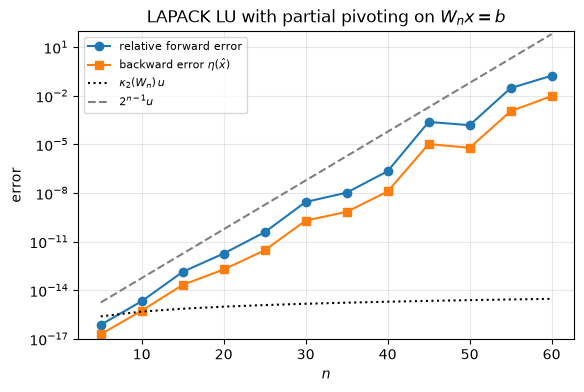

n = 60: forward error 1.7e-01, backward error 9.6e-03


In [13]:
ns_w = np.arange(5, 65, 5)
err_w, eta_w = [], []
for n in ns_w:
    W = wilkinson_matrix(n)
    x_true = rng.standard_normal(n)
    b = W @ x_true
    x_hat = sla.lu_solve(sla.lu_factor(W), b)
    err_w.append(np.linalg.norm(x_hat - x_true) / np.linalg.norm(x_true))
    eta_w.append(np.linalg.norm(b - W @ x_hat) / (np.linalg.norm(W, 2) * np.linalg.norm(x_hat) + np.linalg.norm(b)))

fig, ax = plt.subplots()
ax.semilogy(ns_w, err_w, "o-", label="relative forward error")
ax.semilogy(ns_w, eta_w, "s-", label=r"backward error $\eta(\hat x)$")
ax.semilogy(ns_w, [np.linalg.cond(wilkinson_matrix(n)) * u for n in ns_w], "k:", label=r"$\kappa_2(W_n)\,u$")
ax.semilogy(ns_w, 2.0 ** (ns_w - 1) * u, "--", color="0.5", label=r"$2^{n-1}u$")
ax.set_ylim(1e-17, 1e2)
ax.set_xlabel("$n$")
ax.set_ylabel("error")
ax.set_title(r"LAPACK LU with partial pivoting on $W_n x = b$")
ax.legend(fontsize=8)
plt.show()
print(f"n = 60: forward error {err_w[-1]:.1e}, backward error {eta_w[-1]:.1e}")
# kappa_2(W_60) * u is about 3e-15; an error above 1e-3 is a failure of the algorithm
assert err_w[-1] > 1e-3

The errors grow like $2^{n-1}u$, not like $\kappa_2(W_n)u$: this is an instability of
the algorithm, visible in the backward error, not ill conditioning.

**Complete pivoting** chooses the largest entry of the whole active
submatrix and computes $PAQ = LU$. On $W_n$ it keeps the growth factor at 2
and solves the system accurately.

In [14]:
def lu_complete(A):
    """LU with complete pivoting: A[rp][:, cp] = L @ U. Returns rp, cp, L, U, rho."""
    A = np.array(A, dtype=float)
    n = A.shape[0]
    rp, cp = np.arange(n), np.arange(n)
    amax = np.max(np.abs(A))
    top = amax
    for k in range(n - 1):
        i, j = np.unravel_index(np.argmax(np.abs(A[k:, k:])), (n - k, n - k))
        i, j = i + k, j + k
        A[[k, i]] = A[[i, k]]
        rp[[k, i]] = rp[[i, k]]
        A[:, [k, j]] = A[:, [j, k]]
        cp[[k, j]] = cp[[j, k]]
        if A[k, k] == 0.0:           # the whole active submatrix is zero
            break
        A[k + 1:, k] /= A[k, k]
        A[k + 1:, k + 1:] -= np.outer(A[k + 1:, k], A[k, k + 1:])
        top = max(top, np.max(np.abs(A[k + 1:, k + 1:])))
    return rp, cp, np.tril(A, -1) + np.eye(n), np.triu(A), top / amax


def solve_complete(rp, cp, L, U, b):
    z = back_sub(U, forward_sub(L, np.asarray(b, dtype=float)[rp], unit=True))
    x = np.empty_like(z)
    x[cp] = z                        # A[rp][:, cp] z = b[rp]  means  x[cp] = z
    return x


for n in (10, 20, 60):
    W = wilkinson_matrix(n)
    x_true = rng.standard_normal(n)
    rp, cp, L, U, rho_c = lu_complete(W)
    x_hat = solve_complete(rp, cp, L, U, W @ x_true)
    err = np.linalg.norm(x_hat - x_true) / np.linalg.norm(x_true)
    print(f"n = {n}: complete pivoting growth = {rho_c}, forward error = {err:.1e}")
    assert rho_c == 2.0
    assert err < 10 * n * np.linalg.cond(W) * u     # backward stable with rho = 2: error O(n kappa u)

n = 10: complete pivoting growth = 2.0, forward error = 1.1e-16
n = 20: complete pivoting growth = 2.0, forward error = 2.9e-16
n = 60: complete pivoting growth = 2.0, forward error = 3.5e-16


### Random matrices

For Gaussian random matrices the growth factor of partial pivoting is small.
Trefethen and Schreiber (1990) report that the average growth, measured as the
largest entry during elimination divided by the standard deviation of the
entries, is close to $n^{2/3}$. We compute $\rho_n$ with our own code (which
tracks all intermediate matrices) for moderate $n$, and the cheaper
$\max|u_{ij}|/\sigma$ with LAPACK for larger $n$. These are observations on
random samples, not bounds.

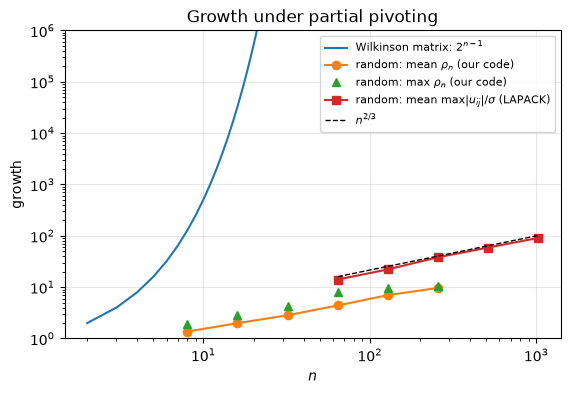

n =    8: mean rho =   1.37, max rho =   1.93, 2^(n-1) = 1.3e+02
n =   16: mean rho =   1.99, max rho =   2.81, 2^(n-1) = 3.3e+04
n =   32: mean rho =   2.84, max rho =   4.26, 2^(n-1) = 2.1e+09
n =   64: mean rho =   4.39, max rho =   8.22, 2^(n-1) = 9.2e+18
n =  128: mean rho =   7.00, max rho =   9.66, 2^(n-1) = 1.7e+38
n =  256: mean rho =   9.64, max rho =  10.38, 2^(n-1) = 5.8e+76
n =   64: mean max|u_ij| / sigma =   14.1,  n^(2/3) =   16.0
n =  128: mean max|u_ij| / sigma =   22.2,  n^(2/3) =   25.4
n =  256: mean max|u_ij| / sigma =   38.2,  n^(2/3) =   40.3
n =  512: mean max|u_ij| / sigma =   59.0,  n^(2/3) =   64.0
n = 1024: mean max|u_ij| / sigma =   90.9,  n^(2/3) =  101.6


In [15]:
ns = [8, 16, 32, 64, 128, 256]
rho_mean, rho_max = [], []
for n in ns:
    trials = 20 if n <= 64 else 6
    r = [lu_partial(rng.standard_normal((n, n)))[4] for _ in range(trials)]
    rho_mean.append(np.mean(r))
    rho_max.append(np.max(r))

ns_big = [64, 128, 256, 512, 1024]
ts_ratio = []
for n in ns_big:
    vals = [np.max(np.abs(np.triu(sla.lu_factor(rng.standard_normal((n, n)))[0]))) for _ in range(5)]
    ts_ratio.append(np.mean(vals))            # entries have standard deviation 1

ns_w = np.arange(2, 40)
fig, ax = plt.subplots()
ax.semilogy(ns_w, 2.0 ** (ns_w - 1), "-", label=r"Wilkinson matrix: $2^{n-1}$")
ax.loglog(ns, rho_mean, "o-", label=r"random: mean $\rho_n$ (our code)")
ax.loglog(ns, rho_max, "^", label=r"random: max $\rho_n$ (our code)")
ax.loglog(ns_big, ts_ratio, "s-", label=r"random: mean $\max|u_{ij}|/\sigma$ (LAPACK)")
ax.loglog(ns_big, np.array(ns_big) ** (2 / 3), "k--", lw=1, label=r"$n^{2/3}$")
ax.set_ylim(1, 1e6)
ax.set_xlabel("$n$")
ax.set_ylabel("growth")
ax.set_title("Growth under partial pivoting")
ax.legend(fontsize=8)
plt.show()
for n, m, mx in zip(ns, rho_mean, rho_max):
    print(f"n = {n:4d}: mean rho = {m:6.2f}, max rho = {mx:6.2f}, 2^(n-1) = {2.0 ** (n - 1):.1e}")
for n, t in zip(ns_big, ts_ratio):
    print(f"n = {n:4d}: mean max|u_ij| / sigma = {t:6.1f},  n^(2/3) = {n ** (2 / 3):6.1f}")

The observed growth stays in the single or low double digits and increases
slowly, in line with the $n^{2/3}$ behavior reported by Trefethen and
Schreiber. The worst case $2^{n-1}$ is attained by special matrices such as
$W_n$, but such matrices are rare in practice.

## 6. Backward error, forward error and conditioning

We now solve $Ax = b$ with LAPACK (`lu_factor`, `lu_solve`) for $n = 100$ and
matrices $A = Q_1\Sigma Q_2^T$ with random orthogonal $Q_1, Q_2$ and singular
values spaced logarithmically from $1$ to $1/\kappa$, so that
$\kappa_2(A) = \kappa$. For each solve we compute the normwise backward error
[(5.9)](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#equation-ch05-eq-rigal) in the $\infty$-norm and verify it against the a
posteriori bound obtained from [Theorem 5.5](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05-thm-solve-backward):
$(A+\Delta A)\hat x = b$ with $|\Delta A|\le\gamma_{3n}|\hat L||\hat U|$
gives $\eta_\infty(\hat x)\le\gamma_{3n}\||\hat L||\hat U|\|_\infty/\|A\|_\infty$,
to which we add $\gamma_{n+1}$ for the rounding errors in computing the
residual.

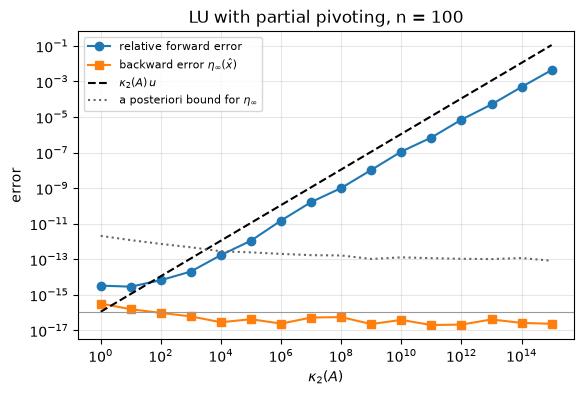

backward errors: min 0.18 u, max 2.88 u
largest ratio forward error / (kappa u): 29.5


In [16]:
def random_with_cond(n, kappa, rng):
    Q1, _ = np.linalg.qr(rng.standard_normal((n, n)))
    Q2, _ = np.linalg.qr(rng.standard_normal((n, n)))
    return (Q1 * np.logspace(0, -np.log10(kappa), n)) @ Q2.T


def eta_normwise(A, x, b, p=np.inf):
    """Rigal-Gaches normwise backward error ||b - A x|| / (||A|| ||x|| + ||b||)."""
    return np.linalg.norm(b - A @ x, p) / (np.linalg.norm(A, p) * np.linalg.norm(x, p) + np.linalg.norm(b, p))


n = 100
kappas = np.logspace(0, 15, 16)
etas, fwds, bounds = [], [], []
for kappa in kappas:
    A = random_with_cond(n, kappa, rng)
    x_true = rng.standard_normal(n)
    b = A @ x_true
    lu, piv = sla.lu_factor(A)
    x_hat = sla.lu_solve((lu, piv), b)
    L, U = np.tril(lu, -1) + np.eye(n), np.triu(lu)
    eta = eta_normwise(A, x_hat, b)
    bound = gamma(3 * n) * np.linalg.norm(np.abs(L) @ np.abs(U), np.inf) / np.linalg.norm(A, np.inf) + gamma(n + 1)
    assert eta <= bound
    etas.append(eta)
    bounds.append(bound)
    fwds.append(np.linalg.norm(x_hat - x_true, np.inf) / np.linalg.norm(x_true, np.inf))

fig, ax = plt.subplots()
ax.loglog(kappas, fwds, "o-", label="relative forward error")
ax.loglog(kappas, etas, "s-", label=r"backward error $\eta_\infty(\hat x)$")
ax.loglog(kappas, kappas * u, "k--", label=r"$\kappa_2(A)\,u$")
ax.loglog(kappas, bounds, ":", color="0.4", label=r"a posteriori bound for $\eta_\infty$")
ax.axhline(u, color="0.6", lw=0.8)
ax.set_xlabel(r"$\kappa_2(A)$")
ax.set_ylabel("error")
ax.set_title("LU with partial pivoting, n = 100")
ax.legend(fontsize=8)
plt.show()
print(f"backward errors: min {min(etas) / u:.2f} u, max {max(etas) / u:.2f} u")
print(f"largest ratio forward error / (kappa u): {max(f / (k * u) for f, k in zip(fwds, kappas)):.1f}")

The backward error is of order $u$ regardless of $\kappa(A)$: LU with partial
pivoting is backward stable on these matrices. For well-conditioned matrices
the forward error is a modest multiple of $u$ (the $\infty$-norm condition
number can exceed $\kappa_2$ by a factor up to $n$); for ill-conditioned
matrices it tracks $\kappa(A)u$, exactly as the perturbation theory of
[Chapter 4](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04) predicts for a backward stable method. The a
posteriori bound is a rigorous guarantee but pessimistic by several orders
of magnitude.

## 7. LU in practice

### Timing the factorization

`scipy.linalg.lu_factor` calls LAPACK's blocked `getrf`. The flop count is
$\tfrac23n^3$; the run times below are observations on the machine that
executed this notebook, reported as the median of several repetitions.

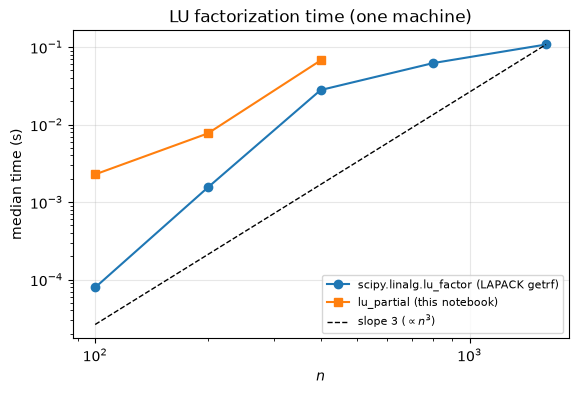

n =   100:     0.08 ms,    8.4 Gflop/s (counting 2n^3/3 flops)
n =   200:     1.55 ms,    3.4 Gflop/s (counting 2n^3/3 flops)
n =   400:    27.93 ms,    1.5 Gflop/s (counting 2n^3/3 flops)
n =   800:    62.29 ms,    5.5 Gflop/s (counting 2n^3/3 flops)
n =  1600:   108.05 ms,   25.3 Gflop/s (counting 2n^3/3 flops)
n = 1600: time(A @ B) / time(lu_factor) = 0.3  (flop ratio 3)


In [17]:
def median_time(f, *args, repeats=5):
    f(*args)                          # warm-up
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        f(*args)
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


sizes = [100, 200, 400, 800, 1600]
t_lu = [median_time(sla.lu_factor, rng.standard_normal((n, n)), repeats=3) for n in sizes]
t_py = [median_time(lu_partial, rng.standard_normal((n, n)), repeats=3) for n in sizes[:3]]

fig, ax = plt.subplots()
ax.loglog(sizes, t_lu, "o-", label="scipy.linalg.lu_factor (LAPACK getrf)")
ax.loglog(sizes[:3], t_py, "s-", label="lu_partial (this notebook)")
ref = np.array(sizes, dtype=float)
ax.loglog(ref, t_lu[-1] * (ref / ref[-1]) ** 3, "k--", lw=1, label=r"slope 3 ($\propto n^3$)")
ax.set_xlabel("$n$")
ax.set_ylabel("median time (s)")
ax.set_title("LU factorization time (one machine)")
ax.legend(fontsize=8)
plt.show()
for n, t in zip(sizes, t_lu):
    print(f"n = {n:5d}: {t * 1e3:8.2f} ms, {2 * n**3 / 3 / t / 1e9:6.1f} Gflop/s (counting 2n^3/3 flops)")
C = rng.standard_normal((sizes[-1], sizes[-1]))
t_mm = median_time(np.matmul, C, C, repeats=3)
print(f"n = {sizes[-1]}: time(A @ B) / time(lu_factor) = {t_mm / t_lu[-1]:.1f}  (flop ratio 3)")

Only the slope is predicted by the flop count, and only for large $n$. On
an otherwise idle machine the rate of `lu_factor` increases with $n$, because
the blocked algorithm performs most of its flops in matrix-matrix products;
only as $n\to\infty$ does the time ratio to `A @ B` tend to the flop ratio 3.
For moderate $n$ the panel factorizations and the pivoting, which are
level-2 operations, keep the rate of `lu_factor` well below that of the
matrix product, so the measured ratio is usually far below 3. For small $n$, fixed overheads and the
thread management of the BLAS library dominate, and on a busy machine the
measurements can be erratic; rerun the cell before drawing conclusions. Our
NumPy implementation performs the same flops in rank-one (level-2) updates
driven by a Python loop and is much slower.

### Factor once, solve many times

With $k$ right-hand sides, solving each system from scratch costs
$k(\tfrac23n^3 + 2n^2)$ flops, while factoring once and reusing the factors
costs $\tfrac23n^3 + 2kn^2$.

In [18]:
n, k = 300, 20
A = rng.standard_normal((n, n))
B = rng.standard_normal((n, k))


def solve_each():
    return np.column_stack([sla.solve(A, B[:, j]) for j in range(k)])


def factor_then_solve_each():
    f = sla.lu_factor(A)
    return np.column_stack([sla.lu_solve(f, B[:, j]) for j in range(k)])


def factor_then_solve_block():
    return sla.lu_solve(sla.lu_factor(A), B)


t1 = median_time(solve_each, repeats=3)
t2 = median_time(factor_then_solve_each, repeats=3)
t3 = median_time(factor_then_solve_block, repeats=3)
print(f"{k} separate solves:              {t1 * 1e3:8.1f} ms")
print(f"one factorization + {k} solves:   {t2 * 1e3:8.1f} ms")
print(f"one factorization + block solve:  {t3 * 1e3:8.1f} ms")
print(f"flop ratio predicted for the first two: {k * (2 * n**3 / 3 + 2 * n**2) / (2 * n**3 / 3 + 2 * k * n**2):.1f}")
X1, X3 = solve_each(), factor_then_solve_block()
# Both are backward stable with small growth, so each has forward error O(n kappa u) ||x||;
# their difference is at most twice that.
assert np.max(np.abs(X1 - X3)) <= 20 * n * u * np.linalg.cond(A) * np.max(np.abs(X1))

20 separate solves:                 105.5 ms
one factorization + 20 solves:        5.5 ms
one factorization + block solve:       5.8 ms
flop ratio predicted for the first two: 16.8


Reusing the factorization saves most of the work, as the flop count predicts;
the measured ratio differs from the flop ratio because each call also has a
fixed overhead and because the level-3 BLAS runs at a higher rate than the
level-2 triangular solves. Passing all right-hand sides at once (a matrix
`B`) is typically fastest, since the triangular solves then become level-3 `trsm`
operations. In practice, the right-hand sides often arrive one at a time
(for example in a time-stepping loop); the factorization is then stored and
reused.

### Never form the inverse

Computing $A^{-1}$ costs $2n^3$ flops, three times the factorization, and the
solution $\hat x = \widehat{A^{-1}}b$ is not backward stable: its residual can
be larger than that of the LU solution by a factor up to about $\kappa(A)$.

In [19]:
n = 200
A = random_with_cond(n, 1e10, rng)
x_true = rng.standard_normal(n)
b = A @ x_true
x_lu = sla.lu_solve(sla.lu_factor(A), b)
x_inv = np.linalg.inv(A) @ b
for name, x in [("lu_solve", x_lu), ("inv(A) @ b", x_inv)]:
    print(f"{name:11s}: backward error {eta_normwise(A, x, b, 2):.1e}, "
          f"forward error {np.linalg.norm(x - x_true) / np.linalg.norm(x_true):.1e}")

lu_solve   : backward error 8.2e-17, forward error 1.1e-07
inv(A) @ b : backward error 1.3e-08, forward error 1.6e-06


Both forward errors are of the order of $\kappa(A)u\approx10^{-6}$ or smaller, but only the
LU solution has a backward error of order $u$.

### Determinants

From $PA = LU$, $\det A = (-1)^s\prod_i u_{ii}$, where $s$ is the number of
interchanges. For a random matrix of order 500 the product overflows, while
the sum of logarithms (`numpy.linalg.slogdet`) does not.

In [20]:
n = 500
A = rng.standard_normal((n, n))
lu, piv = sla.lu_factor(A)
s = np.count_nonzero(piv != np.arange(n))
d = np.diag(lu)
sign = (-1) ** s * np.prod(np.sign(d))
logabsdet = np.sum(np.log(np.abs(d)))
sign_np, logabsdet_np = np.linalg.slogdet(A)
with np.errstate(over="ignore"):
    print("numpy.linalg.det:", np.linalg.det(A))
print(f"from lu_factor: sign {sign:+.0f}, log|det| = {logabsdet:.6f}")
print(f"slogdet:        sign {sign_np:+.0f}, log|det| = {logabsdet_np:.6f}")
assert sign == sign_np and abs(logabsdet - logabsdet_np) <= 1e-10 * abs(logabsdet)

numpy.linalg.det: -inf
from lu_factor: sign -1, log|det| = 1300.896147
slogdet:        sign -1, log|det| = 1300.896147


## Common mistakes

- Using the Wilkinson matrix to demonstrate that unpivoted LU fails. Partial
  pivoting makes no interchanges on it, so both methods give identical
  results. Use a small pivot instead.
- Stating that $2^{n-1}$ bounds the growth without pivoting. It bounds
  partial pivoting; without pivoting growth is unbounded.
- Checking `scipy.linalg.lu` with $\|PA - LU\|$. SciPy returns $A = PLU$, so
  the residual is $\|A - PLU\|$.
- Skipping "small" pivots with an absolute threshold. Only an exactly zero
  active column can be skipped, and then the factorization stays exact.
- Solving $Ax = b$ with `inv(A) @ b`, or refactoring $A$ for every right-hand
  side.
- Computing `np.linalg.det(A)` to test for singularity.

## Your turn

1. Modify `lu_partial` to count the comparisons of the pivot search, and
   write `lu_complete` so that it also counts; compare with $n^2/2$ and $n^3/3$.
2. Implement rook pivoting and measure its growth factor on $W_n$ and on
   random matrices.
3. Repeat Section 6 with the componentwise backward error of Oettli and
   Prager, $\max_i|b-A\hat x|_i/(|A||\hat x|+|b|)_i$. Is LU with partial
   pivoting componentwise backward stable on these matrices?
4. Implement the blocked algorithm [Algorithm 5.4](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05-alg-blocked)
   ([Exercise 5.13](https://aalsammani.github.io/numerical-linear-algebra/ch05-lu/notes.html#ch05-ex-blocked)) and compare its speed with `lu_partial`.
5. Find a $3\times3$ matrix for which partial pivoting has growth factor 4,
   and check that $4 = 2^{n-1}$ is the maximum for $n = 3$.

## Key takeaways

- Triangular solves cost $n^2$ flops and are componentwise backward stable;
  LU costs $\tfrac23n^3$ flops.
- Without pivoting, a small pivot causes unbounded growth and wrong answers
  for well-conditioned matrices.
- With partial pivoting the computed solution solves a nearby system with
  $|\Delta A|\le\gamma_{3n}|\hat L||\hat U|$; stability hinges on the growth
  factor, which is at most $2^{n-1}$ (attained by $W_n$, where no rows are
  interchanged) and small in practice.
- Use `lu_factor`/`lu_solve`, reuse factorizations, and never form $A^{-1}$.

## Further reading

Trefethen and Bau (1997), Lectures 20--23; Golub and Van Loan (2013), Chapter 3;
Higham (2002), Chapters 8 and 9; Demmel (1997), Chapter 2; and,
for the average-case behavior of the growth factor, Trefethen and Schreiber (1990).